# **END TO END**

In [1]:
import sys
import tensorflow as tf
import keras


print(f"Phiên bản Python: {sys.version}")
print(f"Phiên bản TensorFlow: {tf.__version__}")
print(f"Phiên bản Keras: {keras.__version__}")


/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

Phiên bản Python: 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:08:06) [GCC 11.3.0]
Phiên bản TensorFlow: 2.12.0
Phiên bản Keras: 2.12.0


In [2]:
!pip show transformers

Name: transformers
Version: 4.30.1
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /opt/conda/lib/python3.10/site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 


In [3]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


import transformers
from transformers import BertTokenizerFast
from transformers import TFBertModel

from sklearn import preprocessing
from sklearn.model_selection import train_test_split


**Xu lý dữ liệu**

In [5]:
def get_maxlen(sentence):
    malen=0
    for se in sentence:
        malen=max(malen,len(se))
    return malen

Xóa các ký tự đặc biệt .. làm sạch data

In [6]:
%%time
import re
#Removes Punctuations
def remove_punctuations(data):
    punct_tag=re.compile(r'[^\w\s]')
    data=punct_tag.sub(r'',data)
    return data


#Removes HTML syntaxes
def remove_html(data):
    html_tag=re.compile(r'<.*?>')
    data=html_tag.sub(r'',data)
    return data

#Removes URL data
def remove_url(data):
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data
# Removes space
def remove_extra_spaces(s):
    s=s.strip()
    return re.sub(r'\s+', ' ', s)
#Removes Emojis
def remove_emoji(data):
    emoji_clean= re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    data=emoji_clean.sub(r'',data)
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data

def Data_ex(z):
    z= remove_punctuations(z)
    z= remove_html(z)
    z= remove_url(z)
    z= remove_emoji(z)
    z= remove_extra_spaces(z)
    return z
    

CPU times: user 7 µs, sys: 2 µs, total: 9 µs
Wall time: 12.6 µs


In [7]:
def print_loi(ss,datarow):
    #print(ss,datarow)
    pass

đánh số lại id nhóm theo câu 

In [8]:
#Đánh số lại cho cột ID
def renumber_id_by_sentence(df):
  df['group_id'] = df.groupby('Sentence').ngroup()
  df = df.sort_values('group_id')
  df.index = pd.RangeIndex(start=1, stop=len(df)+1)
  return df[['group_id','Sentence','Aspect Term','polarity']]

In [9]:
def find_subarray(at, ss,ar):
    #tìm vị trí xuất hiện
    n = len(at)
    m = len(ss)

    for i in range(m - n + 1):
        j = 0
        if ar[i]=='O':
            while j < n and (at[j] == ss[i + j] or  ss[i + j].find(at[j])>=0) :
                j += 1
            if j == n:
                return i
        
    return -1
def create_data_train(df_new):
    #gán nhãn vào câu tách xâu 
    labels = []
    sentences = []
    id_c=[]
    for ind in df_new['group_id'].unique():
        datarow = df_new[df_new['group_id']==ind].reset_index()
        ss = datarow['Sentence'][0].split()
        ar = ["O"] * len(ss)
        for datarowdt in datarow.index:
            at = datarow['Aspect Term'][datarowdt].split()
            value = datarow['polarity'][datarowdt]
            vst = find_subarray(at, ss,ar)
            if vst==-1:
               # print("lỗi:")
                print_loi(ss,datarow['Aspect Term'][datarowdt])
            else:
                ved = vst + len(at) - 1
                for index in range(vst, ved+1):
                    if(index ==vst):
                        if (vst== ved):
                            ar[index] = "S-"+value
                        else:
                            ar[index] = "B-"+value
                    else:
                        if(index ==ved):
                            ar[index] = "E-"+value
                        else:
                            ar[index] = "I-"+value
        sentences.append(ss)
        labels.append(ar)
        id_c.append(ind)
        ar = []

    data = {'id':id_c,'Sentence': sentences, 'Label': labels}
    return_data = pd.DataFrame(data)
    return return_data

def create_data_train_tag(df_new):
    #gán nhãn vào câu tách xâu 
    labels = []
    sentences = []
    id_c=[]
    for ind in df_new['group_id'].unique():
        datarow = df_new[df_new['group_id']==ind].reset_index()
        ss = datarow['Sentence'][0].split()
        ar = ["O"] * len(ss)
        for datarowdt in datarow.index:
            at = datarow['Aspect Term'][datarowdt].split()
            value = datarow['polarity'][datarowdt]
            vst = find_subarray(at, ss,ar)
            if vst==-1:
               # print("lỗi:")
                print_loi(ss,datarow['Aspect Term'][datarowdt])
            else:
                ved = vst + len(at) - 1
                for index in range(vst, ved+1):
                    if(index ==vst):
                        if (vst== ved):
                            ar[index] = "S"
                        else:
                            ar[index] = "B"
                    else:
                        if(index ==ved):
                            ar[index] = "E"
                        else:
                            ar[index] = "I"
        sentences.append(ss)
        labels.append(ar)
        id_c.append(ind)
        ar = []

    data = {'id':id_c,'Sentence': sentences, 'Label': labels}
    return_data = pd.DataFrame(data)
    return return_data

hàm tổng hợp từ dữ liệu thô sang dữ liệu đã xữ lý cho đầu vào

In [10]:
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer

from nltk.stem import SnowballStemmer

from nltk.tokenize import word_tokenize
def format_df(df1):
    # xóa confict , xóa ký tự thừa, nhóm các câu lại, tạo data đúng 
    #final_stopwords_list = stopwords.words('english') + stopwords.words('french')+stopwords.words('russian')
    print("Xữ lý vắn bản")
    df=df1.copy()
    df = df[df['polarity'] != 'conflict']
    df['Sentence']=df['Sentence'].apply(lambda z: remove_punctuations(z))
    df['Sentence']=df['Sentence'].apply(lambda z: remove_html(z))
    df['Sentence']=df['Sentence'].apply(lambda z: remove_url(z))
    df['Sentence']=df['Sentence'].apply(lambda z: remove_emoji(z))
    df['Sentence']=df['Sentence'].apply(lambda z: remove_extra_spaces(z))

    df['Aspect Term']=df['Aspect Term'].apply(lambda z: remove_punctuations(z))
    df['Aspect Term']=df['Aspect Term'].apply(lambda z: remove_html(z))
    df['Aspect Term']=df['Aspect Term'].apply(lambda z: remove_url(z))
    df['Aspect Term']=df['Aspect Term'].apply(lambda z: remove_emoji(z))
    df['Aspect Term']=df['Aspect Term'].apply(lambda z: remove_extra_spaces(z))
    
#     lemmatizer = WordNetLemmatizer()
#     # Lemmatization
#     S=np.array(df['Sentence'])
#     A=np.array(df['Aspect Term'])
#     for i in range(len(S)):
       
       
#         words = nltk.word_tokenize(S[i])
#         words = [lemmatizer.lemmatize(word) for word in words if word not in final_stopwords_list]
#         S[i] = ' '.join(words)
#         words = nltk.word_tokenize(A[i])
#         words = [lemmatizer.lemmatize(word) for word in words if word not in final_stopwords_list]
#         A[i] = ' '.join(words)
    
#     df['Sentence']=S
#     df['Aspect Term']=A
    
    print("nhóm theo câu")
    df = renumber_id_by_sentence(df)
    print("chuẩn hóa input")
    df = create_data_train(df) #{'id':id_c,'Sentence': sentences, 'Label': labels}
    print("ok")
    return df

LabelEncoder cho Y

In [11]:
def process_data(df):
    enc_pos = preprocessing.LabelEncoder()
    
   # unique_values = ['O','B-neutral', 'I-positive', 'I-neutral', 'I-negative', 'B-negative', 'B-positive']
    unique_values = np.unique(df['Label'].sum())
    enc_pos.fit(list(unique_values))
    lb=[]
    for i in df.index:
        lb.append(list(enc_pos.transform(df.loc[i, 'Label'])))
    sentences = np.array(df['Sentence'])
    laber = np.array(lb)
    return sentences, laber, enc_pos
#sentence,pos,enc_pos = process_data(df_train)

In [12]:
# Using BERT Auto-Tokenizer

def tokenize(data,tokenizer,max_len = 256):
    input_ids = list()
    attention_mask = list()
    for i in tqdm(range(len(data))):
        encoded = tokenizer.encode_plus(data[i],
                                        add_special_tokens = True,
                                        max_length = MAX_LEN,
                                        is_split_into_words=True,
                                        return_attention_mask=True,
                                        padding = 'max_length',
                                        truncation=True,return_tensors = 'np')


        input_ids.append(encoded['input_ids'])
        attention_mask.append(encoded['attention_mask'])
    return np.vstack(input_ids),np.vstack(attention_mask)

In [13]:
def tranformer_df(tokenizer,enc_pos,df):
    df=format_df(df)
    sentences = np.array(df['Sentence'])
    lb=[]
    for i in df.index:
        lb.append(list(enc_pos.transform(df.loc[i, 'Label'])))
    laber = np.array(lb)
    input_ids,attention_mask = tokenize(sentences,max_len = MAX_LEN)
    test_tag = list()
    numrl=enc_pos.transform('O')
    for i in range(len(laber)):
        test_tag.append(np.array(laber[i] + numrl * (MAX_LEN-len(laber[i]))))
    return input_ids,attention_mask,test_tag
    

# **Start**

In [14]:
df_laptop_2014 = pd.read_csv("/kaggle/input/muntilg/Laptop_Train_v2.csv")
df_res_2014 = pd.read_csv("/kaggle/input/muntilg/Restaurants_Train_v2.csv")
df_res_vn = pd.read_csv("/kaggle/input/muntilg/Restaurants_vn.csv")
df_res_en = pd.read_csv("/kaggle/input/muntilg/restaurants_english.csv")
df_res_fre = pd.read_csv("/kaggle/input/muntilg/restaurants_french.csv")
df_res_rus= pd.read_csv("/kaggle/input/muntilg/restaurants_russian.csv")
#df=pd.concat([df1, df2],ignore_index=True)
#print(df.iloc[1])

In [15]:
df_en=pd.concat([df_res_2014,df_res_en], axis=0) 

In [16]:
df_en.iloc[1150].Sentence

'the food was undercooked-the sauce watery, and the vegetables raw.'

In [17]:
df_full=pd.concat([df_en,df_res_fre,df_res_rus], axis=0) 

phân tích 

In [18]:
df_full['polarity'].value_counts()

positive    7201
negative    2813
neutral     1114
conflict      92
Name: polarity, dtype: int64

In [19]:
# tăng cường dữ liệu đối với neutral thêm 6614 và  negative thêm 4500
# một câu có nhiều thông tin nhãn nên -> tăng cường trên 1 cầu những câu giống nhau thi phải cùng tăng cường 
# thay thế ở cả aspect term

In [20]:
df_en.head(4)

,id,Sentence,Aspect Term,polarity,from,to
0,3121,But the staff was so horrible to us.,staff,negative,8,13
1,2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62


In [21]:
df=format_df(df_full)
#sentences, laber, enc_pos=process_data(df_full)

Xữ lý vắn bản
nhóm theo câu
chuẩn hóa input
ok


In [22]:
 np.unique(df['Label'].sum())

array(['B-negative', 'B-neutral', 'B-positive', 'E-negative', 'E-neutral',
       'E-positive', 'I-negative', 'I-neutral', 'I-positive', 'O',
       'S-negative', 'S-neutral', 'S-positive'], dtype='<U10')

In [23]:
df.head()

,id,Sentence,Label
0,0,"[15, pour, une, salade, composée, avec, deux, ...","[O, O, O, B-negative, E-negative, O, O, O, O, ..."
1,1,"[160, for, 2, filets, 2, sides, an, appetizer,...","[O, O, O, S-neutral, O, S-neutral, O, S-neutra..."
2,2,"[1850, un, risotto, où, jai, cherché, du, saum...","[O, O, S-negative, O, O, O, O, O, O, O, O, O, ..."
3,3,"[1ère, fois, que, le, service, nest, pas, à, l...","[O, O, O, O, S-negative, O, O, O, O, O, O, O, ..."
4,4,"[2, heures, dattentes, minumum, aucun, service...","[O, O, S-negative, O, O, S-negative, O, S-nega..."


In [24]:

import re
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import random
import nltk
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Tăng cường dữ liệu bằng từ đồng nghĩa
def get_synonyms(word):
    # Lấy danh sách các từ đồng nghĩa của từ cho trước
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name().lower() != word.lower():
                synonyms.add(lemma.name())
    return list(synonyms)

def synonym_replacement(sentence, num_replacements=2):
    # Thay thế từ trong câu bằng từ đồng nghĩa
   
    words = sentence
    new_words = words.copy()
   
    
    for _ in range(num_replacements):
        kt=True
        nb_w_to_rp=random.choice(range(len(words)))
       
        word_to_replace = words[nb_w_to_rp] # Chọn từ ngẫu nhiên để thay thế
        synonyms = get_synonyms(word_to_replace)  # Lấy từ đồng nghĩa
        if len(synonyms) > 0:
            synonym = random.choice(synonyms)  # Chọn ngẫu nhiên một từ đồng nghĩa
            new_words = [synonym if word == word_to_replace else word for word in new_words]
            
    return ' '.join(new_words)


# Áp dụng tăng cường dữ liệu cho cột 'Sentence'
# df['Sentence_augmented'] =df['Sentence']

# for i in df.index:
#     ss=synonym_replacement(df['Sentence'][i])
#     df['Sentence_augmented'][i] = ss.split()

    
    
    #df['Sentence'].apply(lambda x: synonym_replacement(x))

In [26]:
df

,id,Sentence,Label
0,0,"[15, pour, une, salade, composée, avec, deux, ...","[O, O, O, B-negative, E-negative, O, O, O, O, ..."
1,1,"[160, for, 2, filets, 2, sides, an, appetizer,...","[O, O, O, S-neutral, O, S-neutral, O, S-neutra..."
2,2,"[1850, un, risotto, où, jai, cherché, du, saum...","[O, O, S-negative, O, O, O, O, O, O, O, O, O, ..."
3,3,"[1ère, fois, que, le, service, nest, pas, à, l...","[O, O, O, O, S-negative, O, O, O, O, O, O, O, ..."
4,4,"[2, heures, dattentes, minumum, aucun, service...","[O, O, S-negative, O, O, S-negative, O, S-nega..."
...,...,...,...
6004,6004,"[проводила, за, столик, у, окнавид, чудесныйпо...","[O, O, O, O, S-positive, O, O]"
6005,6005,"[сервис, как, он, должен, быть, в, классическо...","[S-positive, O, O, O, O, O, O, O]"
6006,6006,"[солянка, 200, руб, цезарь, 250, стейк, 550, н...","[S-positive, O, O, S-positive, O, S-positive, ..."
6007,6007,"[столики, не, стоят, впритык, думаю, даже, при...","[S-positive, O, O, O, O, O, O, O, O, O, O, O, ..."


In [27]:
# data_augmented = pd.concat([df[['Sentence','Label']],
#                             df[['Sentence_augmented','Label']].rename(columns={'Sentence_augmented': 'Sentence'})],ignore_index=True)

# data_augmented.shape

Tang cuong

In [28]:
df[df['id']==20].Sentence.sum()

['A',
 'bit',
 'breezy',
 'up',
 'there',
 'on',
 'the',
 'mezzanine',
 'from',
 'the',
 'wind',
 'coming',
 'from',
 'the',
 'tracks']

In [29]:
sentences, laber, enc_pos=process_data(df)

In [30]:
enc_pos.classes_

array(['B-negative', 'B-neutral', 'B-positive', 'E-negative', 'E-neutral',
       'E-positive', 'I-negative', 'I-neutral', 'I-positive', 'O',
       'S-negative', 'S-neutral', 'S-positive'], dtype='<U10')

In [31]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(sentences,laber,random_state=42,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((4807,), (1202,), (4807,), (1202,))

In [32]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-multilingual-cased')
MAX_LEN = 256
tokenizer

BertTokenizerFast(name_or_path='bert-base-multilingual-cased', vocab_size=119547, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True)

In [33]:

# Calling tokenization function

def data():    
    input_ids,attention_mask = tokenize(X_train,tokenizer,max_len = MAX_LEN)
    val_input_ids,val_attention_mask = tokenize(X_test,tokenizer,max_len = MAX_LEN)
    return  input_ids,attention_mask,val_input_ids,val_attention_mask
input_ids,attention_mask,val_input_ids,val_attention_mask=data()

100%|██████████| 1202/1202 [00:00<00:00, 4590.74it/s]


In [34]:
# Train Padding
numrl=enc_pos.transform(['O'])
train_tag = list()
for i in range(len(y_train)):
    train_tag.append(np.array(y_train[i] + list(numrl) * (MAX_LEN-len(y_train[i]))))

# TEST:  Checking Padding Length
was = list()
for i in range(len(train_tag)):
    was.append(len(train_tag[i]))
set(was)

# Train Padding
test_tag = list()

for i in range(len(y_test)):
    test_tag.append(np.array(y_test[i] +  list(numrl) * (MAX_LEN-len(y_test[i]))))

# TEST:  Checking Padding Length
was = list()
for i in range(len(test_tag)):
    was.append(len(test_tag[i]))
set(was)

{256}

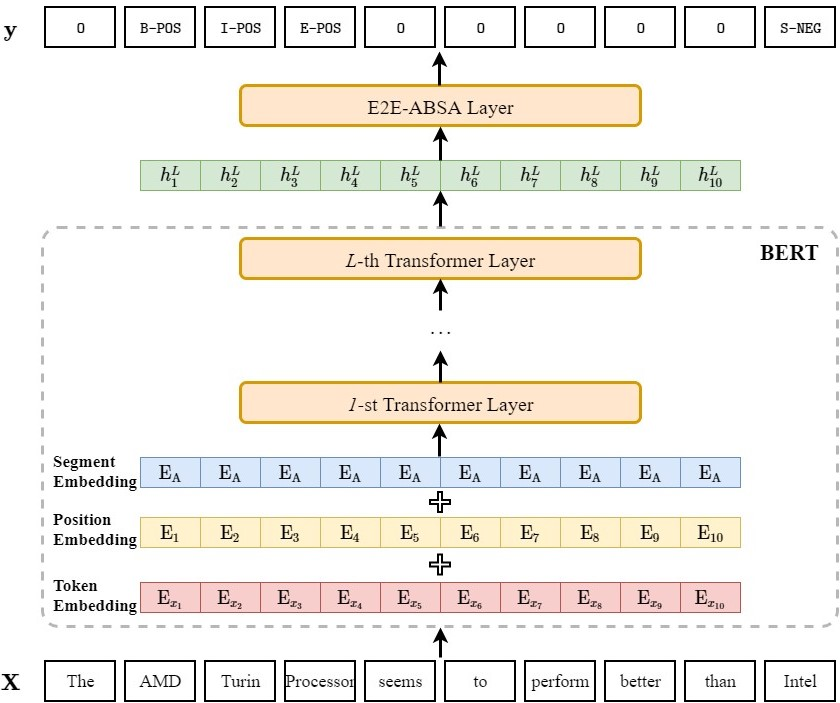

## Bert Modeling

In [35]:
# bert_model = TFBertModel.from_pretrained('bert-base-uncased')

def create_model(bert_model,max_len = MAX_LEN):
    input_ids = tf.keras.Input(shape = (max_len,),dtype = 'int32')
    attention_masks = tf.keras.Input(shape = (max_len,),dtype = 'int32')
    bert_output = bert_model(input_ids,attention_mask = attention_masks,return_dict =True)
    embedding = tf.keras.layers.Dropout(0.1)(bert_output["last_hidden_state"])
    desen = tf.keras.layers.Dense(512,activation = 'relu')(embedding)
    dropout = tf.keras.layers.Dropout(0.2)(desen)
    desen = tf.keras.layers.Dense(256,activation = 'relu')(dropout)
    dropout = tf.keras.layers.Dropout(0.2)(desen)
    desen = tf.keras.layers.Dense(64,activation = 'relu')(dropout)
    output = tf.keras.layers.Dense(14,activation = 'softmax')(desen)
    model = tf.keras.models.Model(inputs = [input_ids,attention_masks],outputs = [output])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# bert_model = TFBertModel.from_pretrained('bert-base-uncased')

def create_model_tag(bert_model,max_len = MAX_LEN):
    input_ids = tf.keras.Input(shape = (max_len,),dtype = 'int32')
    attention_masks = tf.keras.Input(shape = (max_len,),dtype = 'int32')
    bert_output = bert_model(input_ids,attention_mask = attention_masks,return_dict =True)
    embedding = tf.keras.layers.Dropout(0.1)(bert_output["last_hidden_state"])
    desen = tf.keras.layers.Dense(64,activation = 'relu')(embedding)
    output = tf.keras.layers.Dense(4,activation = 'softmax')(desen)
    model = tf.keras.models.Model(inputs = [input_ids,attention_masks],outputs = [output])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [36]:
import tensorflow  as tf
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Device:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()
print('Number of replicas:', strategy.num_replicas_in_sync)

Number of replicas: 1


In [37]:
with strategy.scope():
    bert_model = TFBertModel.from_pretrained('bert-base-multilingual-cased', from_pt=True)
    model_roberta = create_model(bert_model,MAX_LEN)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

In [38]:
model_roberta.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256)]        0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 256)]        0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  177853440   ['input_1[0][0]',                
                                thPoolingAndCrossAt               'input_2[0][0]']                
                                tentions(last_hidde                                               
                                n_state=(None, 256,                                           

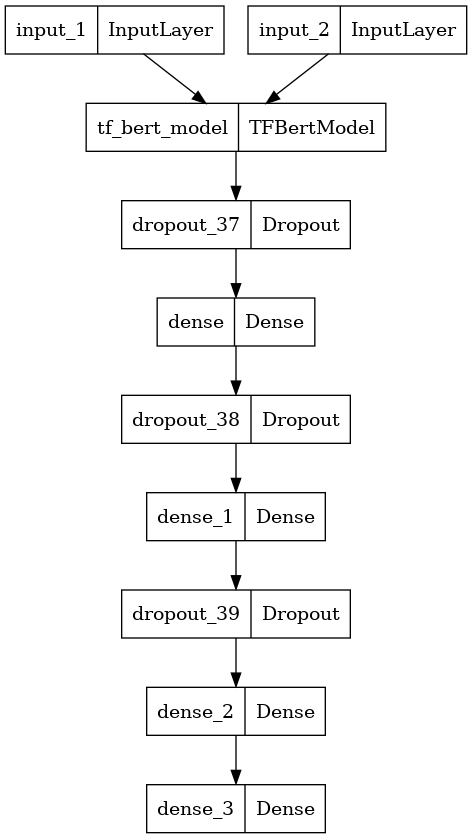

In [39]:
tf.keras.utils.plot_model(model_roberta)

In [40]:
early_stopping = EarlyStopping(mode='min',patience=3)
history_bert = model_roberta.fit([input_ids.copy(),attention_mask.copy()],np.array(train_tag.copy()), validation_split=0.1,epochs = 40,batch_size = 16,callbacks = early_stopping,verbose = True)

Epoch 1/40
271/271 [==============================] - 188s 536ms/step - loss: 0.1437 - accuracy: 0.9762 - val_loss: 0.0450 - val_accuracy: 0.9912
Epoch 2/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0459 - accuracy: 0.9914 - val_loss: 0.0411 - val_accuracy: 0.9912
Epoch 3/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0422 - accuracy: 0.9914 - val_loss: 0.0379 - val_accuracy: 0.9912
Epoch 4/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0386 - accuracy: 0.9914 - val_loss: 0.0355 - val_accuracy: 0.9914
Epoch 5/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0356 - accuracy: 0.9916 - val_loss: 0.0336 - val_accuracy: 0.9918
Epoch 6/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0329 - accuracy: 0.9918 - val_loss: 0.0323 - val_accuracy: 0.9918
Epoch 7/40
271/271 [==============================] - 143s 526ms/step - loss: 0.0304 - accuracy: 0.9921 - val_loss: 0.0307 -

In [41]:
model_roberta.save("/kaggle/working/model/newmodel/best_model",save_format='tf')

## BERT Evaluation

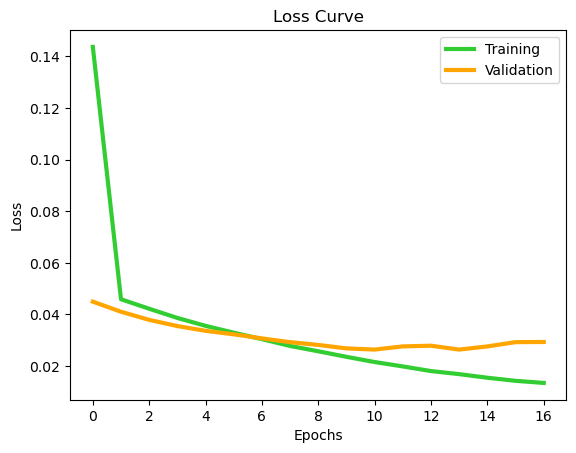

In [42]:
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.plot(history_bert.history['loss'],linewidth=3,color='limegreen')
plt.plot(history_bert.history['val_loss'],linewidth=3,color='orange')  # Plot the chart
plt.legend(["Training", "Validation"], loc ="upper right")

38/38 [==============================] - 15s 322ms/step


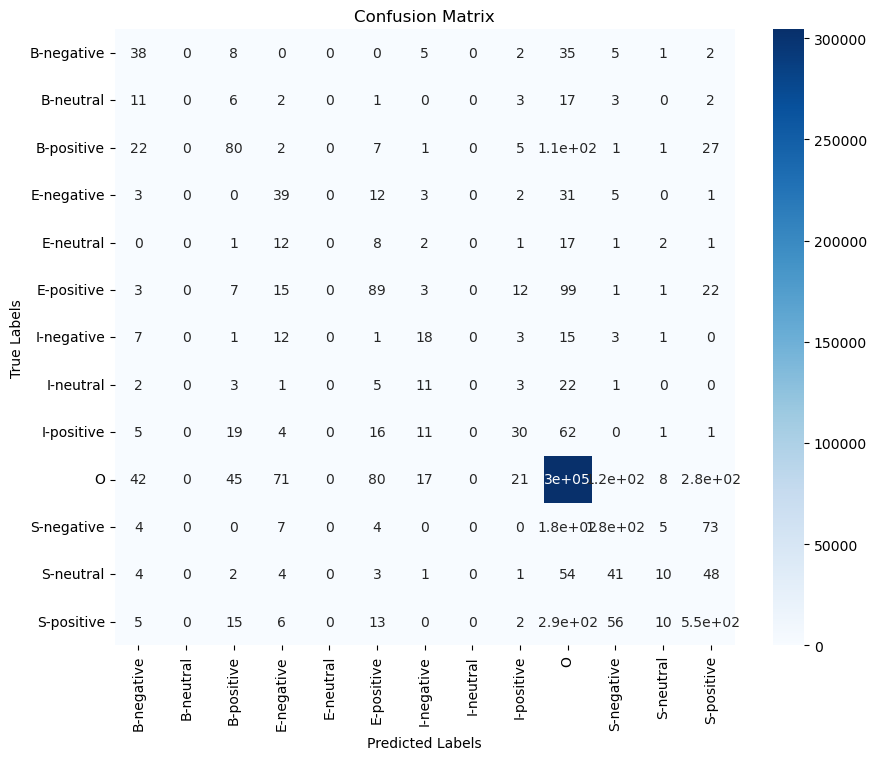

In [43]:
predictions = model_roberta.predict([val_input_ids, val_attention_mask])
#predictions = model.predict([input_ids,attention_mask])
predicted_labels = np.argmax(predictions, axis=2)
true_labels_flat = np.concatenate(test_tag)
predicted_labels_flat = np.concatenate(predicted_labels)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels_flat, predicted_labels_flat)
#cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
import seaborn as sns
label_names = enc_pos.classes_  # Assuming `enc_pos` is the label encoder used in your code

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [44]:
import numpy as np
from sklearn.metrics import classification_report

# Lọc ra nhãn 'O' khỏi dữ liệu
mask = true_labels_flat != 9
y_true_labels_filtered = true_labels_flat[mask]
encoded_pred_labels_filtered = predicted_labels_flat[mask]

# Tên nhãn mới sau khi loại bỏ 'O'
label_names_filtered = [label for label in label_names if label != 9]

# Tính classification report cho các nhãn còn lại
report_filtered = classification_report(y_true_labels_filtered, encoded_pred_labels_filtered, target_names=label_names_filtered)
print(report_filtered)

              precision    recall  f1-score   support

  B-negative       0.37      0.40      0.38        96
   B-neutral       0.00      0.00      0.00        45
  B-positive       0.56      0.32      0.41       252
  E-negative       0.38      0.41      0.39        96
   E-neutral       0.00      0.00      0.00        45
  E-positive       0.56      0.35      0.43       252
  I-negative       0.33      0.30      0.31        61
   I-neutral       0.00      0.00      0.00        48
  I-positive       0.47      0.20      0.28       149
           O       0.00      0.00      0.00         0
  S-negative       0.60      0.40      0.48       443
   S-neutral       0.31      0.06      0.10       168
  S-positive       0.76      0.58      0.66       943

    accuracy                           0.40      2598
   macro avg       0.33      0.23      0.26      2598
weighted avg       0.57      0.40      0.46      2598



In [45]:
y_pred = np.argmax(model_roberta.predict([val_input_ids, val_attention_mask]), axis=2)
y_pred_labels = enc_pos.inverse_transform(y_pred.reshape(-1))
y_true_labels = np.array(test_tag).flatten()
encoded_pred_labels = enc_pos.transform(y_pred_labels)

from sklearn.metrics import classification_report
label_names = enc_pos.inverse_transform(np.arange(len(enc_pos.classes_)))

report = classification_report(y_true_labels, encoded_pred_labels, target_names=label_names) 
print(report)


38/38 [==============================] - 12s 323ms/step
              precision    recall  f1-score   support

  B-negative       0.26      0.40      0.31        96
   B-neutral       0.00      0.00      0.00        45
  B-positive       0.43      0.32      0.36       252
  E-negative       0.22      0.41      0.29        96
   E-neutral       0.00      0.00      0.00        45
  E-positive       0.37      0.35      0.36       252
  I-negative       0.25      0.30      0.27        61
   I-neutral       0.00      0.00      0.00        48
  I-positive       0.35      0.20      0.26       149
           O       1.00      1.00      1.00    305114
  S-negative       0.42      0.40      0.41       443
   S-neutral       0.25      0.06      0.10       168
  S-positive       0.55      0.58      0.56       943

    accuracy                           0.99    307712
   macro avg       0.32      0.31      0.30    307712
weighted avg       0.99      0.99      0.99    307712



Overall accuracy has not increased but the category wise accuracy has increased in many places. Oversampling and pretrained BERT has increase the score

## BERT Conclusion

In [46]:
# Sample sentence
sample_sentence = "The downside to this netbook is pretty much the same for any netbook: screen size is not something I'd stare at for the entire 10-11 hours of battery life five days a week."

#sample_sentence = input("Input: ")
sample_sentence=Data_ex(sample_sentence)
# Tokenize the sample sentence
tokens = tokenizer.encode_plus(np.array(sample_sentence.split()),
                                        add_special_tokens = True,
                                        max_length = MAX_LEN,
                                        is_split_into_words=True,
                                        return_attention_mask=True,
                                        padding = 'max_length',
                                        truncation=True,return_tensors = 'np')


input_ids=tokens['input_ids']
attention_mask=tokens['attention_mask']

# Convert tokens to input IDs and attention mask
# input_ids = tokenizer.convert_tokens_to_ids(tokens)
# attention_mask = [1] * len(input_ids)

# Pad the input IDs and attention mask
input_ids = input_ids #+ [0] * (MAX_LEN - len(input_ids))
attention_mask = attention_mask #+ [0] * (MAX_LEN - len(attention_mask))

# Reshape the input IDs and attention mask for prediction
input_ids = np.array(input_ids).reshape(1, -1)
attention_mask = np.array(attention_mask).reshape(1, -1)

# Make predictions
predictions = model_roberta.predict([input_ids, attention_mask])
predicted_labels = np.argmax(predictions, axis=2)[0]

# Map the predicted labels to their corresponding tag names
predicted_tags = enc_pos.inverse_transform(predicted_labels)
for token, tag in zip(sample_sentence.split(), predicted_tags):
    print(f"Token: {token:<10} Predicted tag: {tag}")
# Print the tokens and predicted POS tags
laber=[]

st=0
for token, tag in zip(sample_sentence.split(), predicted_tags):

    if tag=="O":
        if st==1:
            laber.append(lb)
        st=0
        lb={}
    else:
        lc,po =tag.split('-')
        if lc == 'S':
            if st==0:
                lb['Aspect']=token
                lb['Polarity']=po
                st=0
                laber.append(lb)
            else:
                laber.append(lb)
                lb['Aspect']=token
                lb['Polarity']=po
                st=0
                laber.append(lb)
        if lc=='B':
            if st==0:                
                lb['Aspect']=token
                lb['Polarity']=po                
                st=1
            else:
                laber.append(lb)           
                lb['Aspect']=token
                lb['Polarity']=po
                st=1
        if lc=='I' and st==1:            
            lb['Aspect']=lb['Aspect']+' '+token
        if lc=='E' and st==1:
            lb['Aspect']=lb['Aspect']+' '+token
            st=0
            laber.append(lb)            
           
if st==1:
    laber.append(lb)    
laber

1/1 [==============================] - 0s 48ms/step
Token: The        Predicted tag: O
Token: downside   Predicted tag: O
Token: to         Predicted tag: O
Token: this       Predicted tag: O
Token: netbook    Predicted tag: O
Token: is         Predicted tag: S-negative
Token: pretty     Predicted tag: O
Token: much       Predicted tag: O
Token: the        Predicted tag: O
Token: same       Predicted tag: O
Token: for        Predicted tag: O
Token: any        Predicted tag: O
Token: netbook    Predicted tag: O
Token: screen     Predicted tag: O
Token: size       Predicted tag: B-negative
Token: is         Predicted tag: E-negative
Token: not        Predicted tag: O
Token: something  Predicted tag: O
Token: Id         Predicted tag: O
Token: stare      Predicted tag: O
Token: at         Predicted tag: O
Token: for        Predicted tag: O
Token: the        Predicted tag: O
Token: entire     Predicted tag: O
Token: 1011       Predicted tag: O
Token: hours      Predicted tag: O
Token: of  

[{'Aspect': 'is', 'Polarity': 'negative'},
 {'Aspect': 'size is', 'Polarity': 'negative'}]

# **Bi - LSTM**

In [47]:
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Bidirectional, Layer, Attention,Dropout



# def build_model(max_len=256, input_dim=119547 + 1, embedding_dim=512):
#     # Model definition
#     input_layer = Input(shape=(max_len,))
    
#     # Get embeddings
#     embeddings = Embedding(
#         input_dim,
#         embedding_dim,
#         input_length=max_len,
#         mask_zero=True,
#         trainable=True,
#         name='embedding_layer'
#     )(input_layer)

#     # Variational biLSTM
#     output_sequences1 = Bidirectional(LSTM(units=256, return_sequences=True))(embeddings)
#     output_sequences1 = Bidirectional(LSTM(units=64, return_sequences=True))(embeddings)

#     dropoup = Dropout(0.2)(output_sequences1)
    
 
#     # Adding attention layer
#     desen = tf.keras.layers.Dense(512,activation = 'relu')(embedding)
#     dropout = tf.keras.layers.Dropout(0.2)(desen)
#     desen = tf.keras.layers.Dense(256,activation = 'relu')(dropout)
#     dropout = tf.keras.layers.Dropout(0.2)(desen)
#     desen = tf.keras.layers.Dense(64,activation = 'relu')(dropout)
#     output = tf.keras.layers.Dense(14,activation = 'softmax')(desen)    

#     # Adding more non-linearity
#     dense_out = TimeDistributed(Dense(512, activation="relu"))(dropoup)
#     dropoup = TimeDistributed( Dropout(0.2))(dense_out)
#     dense_out = TimeDistributed(Dense(256, activation="relu"))(dropoup)
#     dense_out = TimeDistributed(Dense(64, activation="relu"))(dense_out)
#     # Output layer
#     output = TimeDistributed(Dense(14, activation='softmax'))(dense_out)

#     model = Model(input_layer, output)
   

#     return model

# model1 = build_model()

# # Checkpointing
# save_model = tf.keras.callbacks.ModelCheckpoint(filepath='ner_crf.h5',
#                                                 monitor='val_loss',
#                                                 save_weights_only=True,
#                                                 save_best_only=True,
#                                                 verbose=1)

# # Early stopping
# es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# model1.summary()

In [48]:
# input_ids,attention_mask,val_input_ids,val_attention_mask=data()
# from tensorflow import keras
# opt = keras.optimizers.Adam(learning_rate=0.0005)
# model1.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history = model1.fit(
#   input_ids.copy(),
#   np.array(train_tag),
#   batch_size=16,
#   epochs=30,
# validation_split=0.1,
#   #validation_data=(val_input_ids.copy(), np.array(test_tag)),

#   #shuffle=True
# )

In [49]:
# from matplotlib import pyplot

# pyplot.plot(history.history['loss'], label='train')
# pyplot.plot(history.history['val_loss'], label='test')
# pyplot.legend()
# pyplot.show()

In [50]:
# predictions = model1.predict(val_input_ids)

In [51]:
# predictions = model1.predict(val_input_ids)
# #predictions = model.predict([input_ids,attention_mask])
# predicted_labels = np.argmax(predictions, axis=2)
# true_labels_flat = np.concatenate(test_tag)
# predicted_labels_flat = np.concatenate(predicted_labels)
# from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(true_labels_flat, predicted_labels_flat)
# #cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# import seaborn as sns
# label_names = enc_pos.classes_  # Assuming `enc_pos` is the label encoder used in your code

# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_names, yticklabels=label_names)
# plt.xlabel('Predicted Labels')
# plt.ylabel('True Labels')
# plt.title('Confusion Matrix')
# plt.show()


In [52]:
# import numpy as np
# from sklearn.metrics import classification_report

# # Lọc ra nhãn 'O' khỏi dữ liệu
# mask = true_labels_flat != 9
# y_true_labels_filtered = true_labels_flat[mask]
# encoded_pred_labels_filtered = predicted_labels_flat[mask]

# # Tên nhãn mới sau khi loại bỏ 'O'
# label_names_filtered = [label for label in label_names if label != 9]

# # Tính classification report cho các nhãn còn lại
# report_filtered = classification_report(y_true_labels_filtered, encoded_pred_labels_filtered, target_names=label_names_filtered)
# print(report_filtered)

In [53]:
# # Sample sentence
# sample_sentence = "The downside to this netbook is pretty much the same for any netbook: screen size is not something I'd stare at for the entire 10-11 hours of battery life five days a week."
# sample_sentence="Boot time is super fast, around anywhere from 35 seconds to 1 minute."
# sample_sentence="The food and drinks were quite good but the service attitude was very bad."

# sample_sentence=Data_ex(sample_sentence)
# # Tokenize the sample sentence
# tokens = tokenizer.encode_plus(np.array(sample_sentence.split()),
#                                         add_special_tokens = True,
#                                         max_length = MAX_LEN,
#                                         is_split_into_words=True,
#                                         return_attention_mask=True,
#                                         padding = 'max_length',
#                                         truncation=True,return_tensors = 'np')


# input_ids=tokens['input_ids']
# attention_mask=tokens['attention_mask']

# # Convert tokens to input IDs and attention mask
# # input_ids = tokenizer.convert_tokens_to_ids(tokens)
# # attention_mask = [1] * len(input_ids)

# # Pad the input IDs and attention mask
# input_ids = input_ids #+ [0] * (MAX_LEN - len(input_ids))
# attention_mask = attention_mask #+ [0] * (MAX_LEN - len(attention_mask))

# # Reshape the input IDs and attention mask for prediction
# input_ids = np.array(input_ids).reshape(1, -1)
# attention_mask = np.array(attention_mask).reshape(1, -1)

# # Make predictions
# predictions = model1.predict(input_ids)
# predicted_labels = np.argmax(predictions, axis=2)[0]

# # Map the predicted labels to their corresponding tag names
# predicted_tags = enc_pos.inverse_transform(predicted_labels)

# # Print the tokens and predicted POS tags
# for token, tag in zip(sample_sentence.split(), predicted_tags):
#     print(f"Token: {token:<10} Predicted POS: {tag}")
    
# laber=[]

# st=0
# lb={}
# for token, tag in zip(sample_sentence.split(), predicted_tags):

#     if tag=="O":
#         if st==1:
#             laber.append(lb)
#         st=0
#         lb={}
#     else:
#         lc,po =tag.split('-')
#         if lc == 'S':
#             if st==0:
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=0
#                 laber.append(lb)
#             else:
#                 laber.append(lb)
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=0
#                 laber.append(lb)
#         if lc=='B':
#             if st==0:                
#                 lb['Aspect']=token
#                 lb['Polarity']=po                
#                 st=1
#             else:
#                 laber.append(lb)           
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=1
#         if lc=='I' and st==1:            
#             lb['Aspect']=lb['Aspect']+' '+token
#         if lc=='E' and st==1:
#             lb['Aspect']=lb['Aspect']+' '+token
#             st=0
#             laber.append(lb)            
           
# if st==1:
#     laber.append(lb)    
# laber

# **CNN _Bi LSTM**

In [54]:

 input_ids,attention_mask,val_input_ids,val_attention_mask=data()
model_CNN_RNN_Bilstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256,), dtype='int32'),
    tf.keras.layers.Embedding(119547,256),
    tf.keras.layers.Conv1D(filters=64, kernel_size=2, padding='same', activation='relu'),
    tf.keras.layers.Conv1D(filters=64, kernel_size=2, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=1),
    tf.keras.layers.Conv1D(filters=128, kernel_size=2, padding='same', activation='relu'),
    tf.keras.layers.Conv1D(filters=128, kernel_size=2, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=1),
   
   
    
    tf.keras.layers.Dropout(0.4),
    #tf.keras.layers.Flatten(),
    #tf.keras.layers.LSTM(100,return_sequences=True),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(256,return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,return_sequences=True)),
   # tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(512)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
     tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(14, activation='softmax')
])
model_CNN_RNN_Bilstm.summary()


from tensorflow import keras
opt = keras.optimizers.Adam(learning_rate=0.0005)
model_CNN_RNN_Bilstm.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model_CNN_RNN_Bilstm.fit(
  input_ids.copy(),
  np.array(train_tag),
  batch_size=16,
  epochs=30,
  validation_split=0.1
  #validation_data=(val_input_ids.copy(), np.array(test_tag)),
 # callbacks=callbacks,
  #shuffle=True
)


100%|██████████| 1202/1202 [00:00<00:00, 4434.05it/s]


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 256, 256)          30604032  
                                                                 
 conv1d (Conv1D)             (None, 256, 64)           32832     
                                                                 
 conv1d_1 (Conv1D)           (None, 256, 64)           8256      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 256, 64)          0         
 )                                                               
                                                                 
 conv1d_2 (Conv1D)           (None, 256, 128)          16512     
                                                                 
 conv1d_3 (Conv1D)           (None, 256, 128)          32896     
                                                        

38/38 [==============================] - 2s 31ms/step


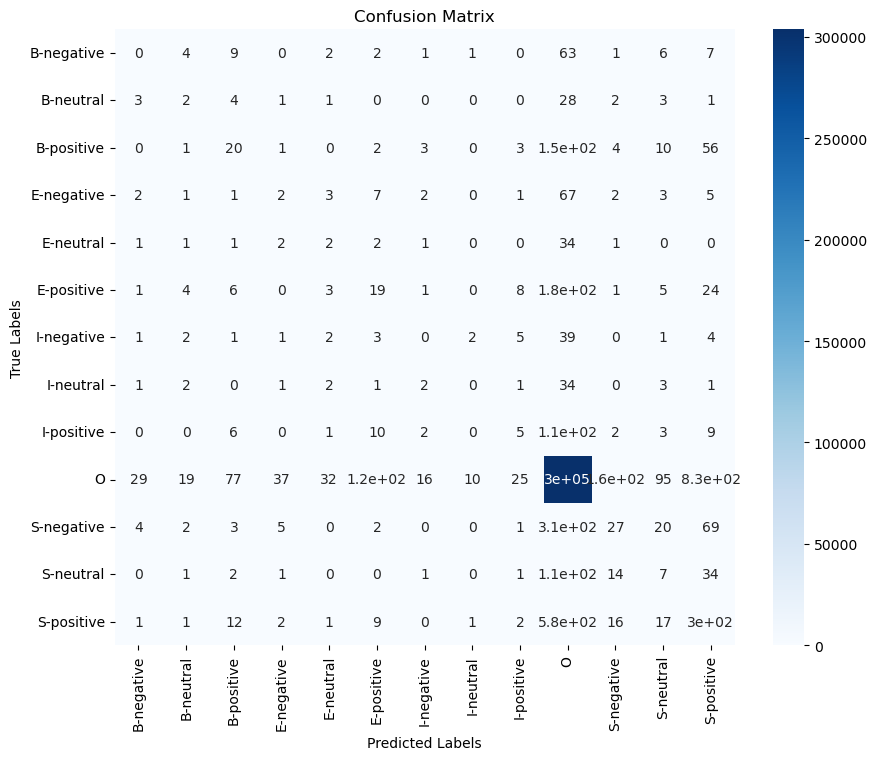

In [55]:
predictions = model_CNN_RNN_Bilstm.predict(val_input_ids)
#predictions = model.predict([input_ids,attention_mask])
predicted_labels = np.argmax(predictions, axis=2)
true_labels_flat = np.concatenate(test_tag)
predicted_labels_flat = np.concatenate(predicted_labels)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels_flat, predicted_labels_flat)
#cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
import seaborn as sns
label_names = enc_pos.classes_  # Assuming `enc_pos` is the label encoder used in your code

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [56]:
import numpy as np
from sklearn.metrics import classification_report

# Lọc ra nhãn 'O' khỏi dữ liệu
mask = true_labels_flat != 9
y_true_labels_filtered = true_labels_flat[mask]
encoded_pred_labels_filtered = predicted_labels_flat[mask]

# Tên nhãn mới sau khi loại bỏ 'O'
label_names_filtered = [label for label in label_names if label != 9]

# Tính classification report cho các nhãn còn lại
report_filtered = classification_report(y_true_labels_filtered, encoded_pred_labels_filtered, target_names=label_names_filtered)
print(report_filtered)

              precision    recall  f1-score   support

  B-negative       0.00      0.00      0.00        96
   B-neutral       0.10      0.04      0.06        45
  B-positive       0.31      0.08      0.13       252
  E-negative       0.12      0.02      0.04        96
   E-neutral       0.12      0.04      0.06        45
  E-positive       0.33      0.08      0.12       252
  I-negative       0.00      0.00      0.00        61
   I-neutral       0.00      0.00      0.00        48
  I-positive       0.19      0.03      0.06       149
           O       0.00      0.00      0.00         0
  S-negative       0.39      0.06      0.11       443
   S-neutral       0.09      0.04      0.06       168
  S-positive       0.58      0.31      0.41       943

    accuracy                           0.15      2598
   macro avg       0.17      0.05      0.08      2598
weighted avg       0.37      0.15      0.20      2598



In [57]:
# dir_path="/kaggle/working/model/newmodel/best_model"
# model =  tf.keras.models.load_model(
#     dir_path,
#     custom_objects={"TFBertModel": TFBertModel}
# )

In [58]:
# # Sample sentence
# sample_sentence = "I don't like this food"

# #sample_sentence = input("Input: ")
# sample_sentence=Data_ex(sample_sentence)
# # Tokenize the sample sentence
# tokens = tokenizer.encode_plus(np.array(sample_sentence.split()),
#                                         add_special_tokens = True,
#                                         max_length = MAX_LEN,
#                                         is_split_into_words=True,
#                                         return_attention_mask=True,
#                                         padding = 'max_length',
#                                         truncation=True,return_tensors = 'np')


# input_ids=tokens['input_ids']
# attention_mask=tokens['attention_mask']

# # Convert tokens to input IDs and attention mask
# # input_ids = tokenizer.convert_tokens_to_ids(tokens)
# # attention_mask = [1] * len(input_ids)

# # Pad the input IDs and attention mask
# input_ids = input_ids #+ [0] * (MAX_LEN - len(input_ids))
# attention_mask = attention_mask #+ [0] * (MAX_LEN - len(attention_mask))

# # Reshape the input IDs and attention mask for prediction
# input_ids = np.array(input_ids).reshape(1, -1)
# attention_mask = np.array(attention_mask).reshape(1, -1)

# # Make predictions
# predictions = model_CNN_RNN_Bilstm.predict([input_ids])
# predicted_labels = np.argmax(predictions, axis=2)[0]

# # Map the predicted labels to their corresponding tag names
# predicted_tags = enc_pos.inverse_transform(predicted_labels)
# for token, tag in zip(sample_sentence.split(), predicted_tags):
#     print(f"Token: {token:<10} Predicted tag: {tag}")
# # Print the tokens and predicted POS tags
# laber=[]

# st=0
# for token, tag in zip(sample_sentence.split(), predicted_tags):

#     if tag=="O":
#         if st==1:
#             laber.append(lb)
#         st=0
#         lb={}
#     else:
#         lc,po =tag.split('-')
#         if lc == 'S':
#             if st==0:
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=0
#                 laber.append(lb)
#             else:
#                 laber.append(lb)
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=0
#                 laber.append(lb)
#         if lc=='B':
#             if st==0:                
#                 lb['Aspect']=token
#                 lb['Polarity']=po                
#                 st=1
#             else:
#                 laber.append(lb)           
#                 lb['Aspect']=token
#                 lb['Polarity']=po
#                 st=1
#         if lc=='I' and st==1:            
#             lb['Aspect']=lb['Aspect']+' '+token
#         if lc=='E' and st==1:
#             lb['Aspect']=lb['Aspect']+' '+token
#             st=0
#             laber.append(lb)            
           
# if st==1:
#     laber.append(lb)    
# laber